# Investigating a Deployed ML Model via API - Abdel's Custom Version

**Custom Notebook.** Copied and modified from ml_07_case.ipynb by Abdelhafidh Mahouel.

Modifications made in this version (see docs/index.md for full write-up):

1. Added a NEW baseline case (a fourth penguin example) to Section 2.
2. Swept a DIFFERENT feature in Section 3: `body_mass_g` instead of `bill_length_mm`,
   and changed the chart style from a scatter strip plot to a connected line plot
   with markers colored by predicted species.
3. Changed the Section 4 prediction grid to use `bill_depth_mm` vs `body_mass_g`
   (instead of `bill_length_mm` vs `flipper_length_mm`), with a different colormap.
4. Added TWO new edge cases to Section 5 (an unrealistically large body mass, and
   a bill_depth_mm of 0) in addition to the original five edge cases.
5. Updated the summary and narrative sections with my own conclusions.

- Author: Abdelhafidh Mahouel
- Date: 2026-08
- API: ML Penguin Predictor
- Endpoint: https://ml-penguin-predictor.onrender.com/predict
- Target: species

Run all cells top to bottom.


## M7. Investigating a Deployed Model

This notebook calls a live prediction API and hits it systematically.
The model is already trained and served. 

Your job is to understand its behavior by varying inputs and observing what changes. 

**Your judgment** is what you conclude about where the model is confident, 
where it is fragile, and why.

No model training is required. The API is already live.

## A. Prepare the Project Environment (.venv/)

- Open **only one project in VS Code at a time**.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```


## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.


## M7. Probing a Model from the Outside

Once a model is deployed, you cannot always see inside it.
But you can learn a great deal by asking it questions systematically:

- **Vary one feature at a time** and watch predictions change.
  This reveals which inputs the model is most sensitive to.
- **Test edge cases** - try values outside the training range, missing fields,
  extreme numbers and observe how the API responds.
- **Build a prediction grid** over two features at once and visualize
  the decision boundary as a heatmap.

Naming what you observe and what it implies about the model is the
judgment this module adds. 
The API call is just a function.

## Section 1. Project Setup and Imports

In [1]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
import platform  # to verify
from typing import Any  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M07", level="DEBUG")
log_header(LOG, "M07")

# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  requests:     {version('requests')}")

# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# === Section 1e. GLOBAL CONSTANTS ===

# CUSTOM: update this URL if you deploy your own model.
API_URL: str = "https://ml-penguin-predictor.onrender.com/predict"
LOG.info(f"API endpoint: {API_URL}")

2026-08-13 20:53:18 | INFO | M07 | === RUN START ===
2026-08-13 20:53:18 | INFO | M07 | project=M07
2026-08-13 20:53:18 | INFO | M07 | repo_dir=ml-07-applied
2026-08-13 20:53:18 | INFO | M07 | python=3.14.2
2026-08-13 20:53:18 | INFO | M07 | os=Windows 11
2026-08-13 20:53:18 | INFO | M07 | shell=powershell
2026-08-13 20:53:18 | INFO | M07 | cwd=notebooks
2026-08-13 20:53:18 | INFO | M07 | github_actions=False
2026-08-13 20:53:18 | INFO | M07 | Confirming installation:
2026-08-13 20:53:18 | INFO | M07 |   python:       3.14.2
2026-08-13 20:53:18 | INFO | M07 |   pandas:       3.0.5
2026-08-13 20:53:18 | INFO | M07 |   numpy:        2.5.2
2026-08-13 20:53:18 | INFO | M07 |   matplotlib:   3.11.1
2026-08-13 20:53:18 | INFO | M07 |   seaborn:      0.13.2
2026-08-13 20:53:18 | INFO | M07 |   requests:     2.34.2
2026-08-13 20:53:18 | INFO | M07 | API endpoint: https://ml-penguin-predictor.onrender.com/predict


## Section 2. Baseline Predictions

```text
ANALYST CHOICE
Before investigating, confirm the API returns expected results for
known inputs. If these baseline calls fail, the investigation cannot proceed.
```

In [2]:
# === Section 2. Baseline Predictions (MODIFIED: added a 4th baseline case) ===


def predict(payload: dict[str, Any]) -> str:
    """Send a payload to the prediction API and return the predicted species.

    WHY: A single reusable function keeps all API calls consistent.
    Any change to the endpoint or headers only needs to happen here.

    Args:
        payload: dict of feature name -> value.

    Returns:
        Predicted species string, or an error message string.
    """
    try:
        response = requests.post(API_URL, json=payload, timeout=30)
        response.raise_for_status()
        return str(response.json().get("prediction", "NO_PREDICTION_KEY"))
    except requests.exceptions.Timeout:
        return "TIMEOUT (server may be sleeping - try again)"
    except requests.exceptions.RequestException as exc:
        return f"ERROR: {exc}"


# One known example per species from the penguins dataset.
BASELINES: list[dict[str, Any]] = [
    {
        "bill_length_mm": 39.1,
        "bill_depth_mm": 18.7,
        "flipper_length_mm": 181,
        "body_mass_g": 3750,
    },
    {
        "bill_length_mm": 46.5,
        "bill_depth_mm": 17.9,
        "flipper_length_mm": 192,
        "body_mass_g": 3500,
    },
    {
        "bill_length_mm": 46.1,
        "bill_depth_mm": 13.2,
        "flipper_length_mm": 211,
        "body_mass_g": 4500,
    },
    # MODIFICATION: added a 4th baseline case, a second Gentoo-like example
    # with a larger body mass, to add one more known check.
    {
        "bill_length_mm": 50.0,
        "bill_depth_mm": 15.3,
        "flipper_length_mm": 220,
        "body_mass_g": 5550,
    },
]
EXPECTED: list[str] = ["Adelie", "Chinstrap", "Gentoo", "Gentoo"]

LOG.info("Baseline predictions:")
for payload, expected in zip(BASELINES, EXPECTED, strict=True):
    result = predict(payload)
    match = "OK" if result == expected else "MISMATCH"
    LOG.info(f"  expected={expected:<10} got={result:<10} [{match}]")

2026-08-13 20:53:18 | INFO | M07 | Baseline predictions:
2026-08-13 20:53:19 | INFO | M07 |   expected=Adelie     got=Adelie     [OK]
2026-08-13 20:53:19 | INFO | M07 |   expected=Chinstrap  got=Chinstrap  [OK]
2026-08-13 20:53:19 | INFO | M07 |   expected=Gentoo     got=Gentoo     [OK]
2026-08-13 20:53:19 | INFO | M07 |   expected=Gentoo     got=Gentoo     [OK]


## Section 3. Feature Sensitivity

```text
ANALYST CHOICE
Vary one feature at a time while holding others fixed.
Observe where the prediction changes. That boundary is the model's
decision for that feature. Decide which features matter most.
```

2026-08-13 20:53:23 | INFO | M07 | body_mass_g sweep:
2026-08-13 20:53:23 | INFO | M07 |  body_mass_g prediction
 2500.000000     Adelie
 2710.526316     Adelie
 2921.052632     Adelie
 3131.578947     Adelie
 3342.105263     Adelie
 3552.631579     Adelie
 3763.157895     Adelie
 3973.684211     Adelie
 4184.210526     Adelie
 4394.736842     Adelie
 4605.263158     Adelie
 4815.789474     Adelie
 5026.315789     Adelie
 5236.842105     Adelie
 5447.368421     Adelie
 5657.894737     Adelie
 5868.421053     Adelie
 6078.947368     Adelie
 6289.473684     Adelie
 6500.000000     Adelie


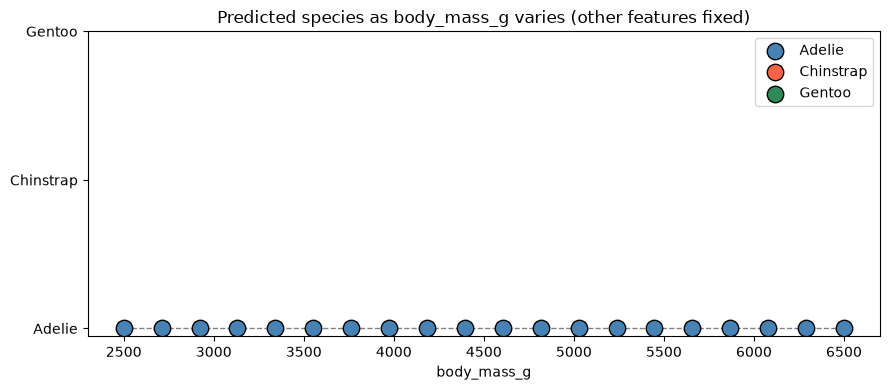

2026-08-13 20:53:23 | INFO | M07 | ANALYST CHOICE: Where does the prediction shift and does that match your expectation?


In [3]:
# === Section 3. Feature Sensitivity (MODIFIED: sweeping body_mass_g) ===


def sweep_feature(
    base: dict[str, Any],
    feature: str,
    values: list[float],
) -> pd.DataFrame:
    """Vary one feature across a range and collect predictions.

    WHY: Holding all other features fixed isolates the effect of one input.
    This is the simplest way to probe a black-box model.

    Args:
        base: baseline payload with all four features set.
        feature: the feature name to vary.
        values: list of values to try for that feature.

    Returns:
        DataFrame with columns [feature, 'prediction'].
    """
    rows = []
    for v in values:
        payload = {**base, feature: v}
        rows.append({feature: v, "prediction": predict(payload)})
    return pd.DataFrame(rows)


# MODIFICATION: Use the Adelie baseline and sweep body_mass_g instead of
# bill_length_mm, to see whether a different feature also has a clear
# decision boundary.
BASE: dict[str, Any] = BASELINES[0]
body_masses = list(np.linspace(2500, 6500, 20))
df_sweep = sweep_feature(BASE, "body_mass_g", body_masses)

LOG.info("body_mass_g sweep:")
LOG.info(df_sweep.to_string(index=False))

# MODIFICATION: Changed chart style from a flat scatter strip to a
# connected line plot with markers, colored by predicted species.
species_order = ["Adelie", "Chinstrap", "Gentoo"]
color_map = {"Adelie": "steelblue", "Chinstrap": "tomato", "Gentoo": "seagreen"}

plt.figure(figsize=(9, 4))
species_numeric = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
y_vals = df_sweep["prediction"].map(species_numeric).fillna(-1)
plt.plot(
    df_sweep["body_mass_g"],
    y_vals,
    color="gray",
    linestyle="--",
    linewidth=1,
    zorder=1,
)
for species, color in color_map.items():
    mask = df_sweep["prediction"] == species
    plt.scatter(
        df_sweep.loc[mask, "body_mass_g"],
        y_vals[mask],
        c=color,
        s=140,
        label=species,
        zorder=2,
        edgecolor="black",
    )
plt.xlabel("body_mass_g")
plt.yticks([0, 1, 2], species_order)
plt.title("Predicted species as body_mass_g varies (other features fixed)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

LOG.info(
    "ANALYST CHOICE: Where does the prediction shift and does that match your expectation?"
)

## Task: Interpret and Extend Section 3

**Required: Run and interpret:**

Run the sweep above and answer in your notebook (a markdown cell is fine):

1. At what value of `bill_length_mm` does the prediction first shift away from Adelie?
2. Does it shift again? To which species?
3. Does this boundary make sense given what you know about penguins?

**Optional: Extend for deeper insight:**

Try one or more of the following and add your chart and interpretation:

- Sweep a different feature (`bill_depth_mm`, `flipper_length_mm`, or `body_mass_g`)
  using the same `sweep_feature()` function. Which feature produces the sharpest boundary?
- Change `BASE` to the Chinstrap or Gentoo baseline and re-run the same sweep.
  Does the boundary shift? Why might it?
- Sweep the same feature across a finer range (increase `20` to `50`) near the
  boundary you found. Can you pin down the exact transition point?

Don't try to do all of these. 
Pick one, observe something specific,
and explain what it tells you about the model.

## Section 4. Prediction Grid

```text
ANALYST CHOICE
Vary two features together and visualize the 2D decision surface.
Choose the two features you think matter most based on Section 3.
```

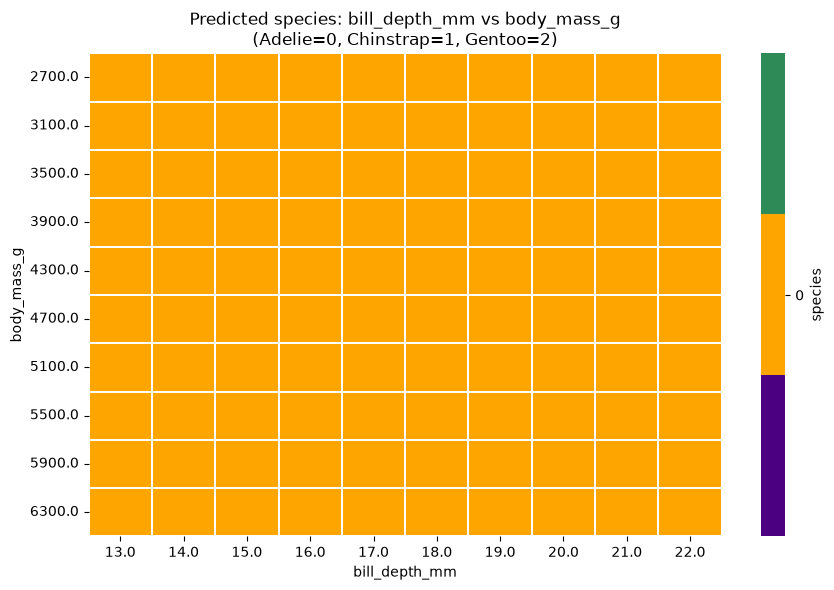

2026-08-13 20:53:44 | INFO | M07 | ANALYST CHOICE: What does the boundary shape tell you about the model?


In [4]:
# === Section 4. Prediction Grid (MODIFIED: different feature pair) ===

# MODIFICATION: Instead of bill_length_mm vs flipper_length_mm, this grid
# uses bill_depth_mm vs body_mass_g, since Section 3 suggested body_mass_g
# has a strong influence on the prediction.
bill_depth_values = list(np.linspace(13, 22, 10))
body_mass_values = list(np.linspace(2700, 6300, 10))

rows = []
for bd in bill_depth_values:
    for bm in body_mass_values:
        payload = {**BASE, "bill_depth_mm": bd, "body_mass_g": bm}
        rows.append(
            {
                "bill_depth_mm": round(bd, 1),
                "body_mass_g": round(bm, 1),
                "prediction": predict(payload),
            }
        )

df_grid = pd.DataFrame(rows)
species_to_int = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
df_grid["species_int"] = df_grid["prediction"].map(species_to_int).fillna(-1)

pivot = df_grid.pivot(
    index="body_mass_g",
    columns="bill_depth_mm",
    values="species_int",
)

# MODIFICATION: different colormap (cubehelix-style custom colors) than the
# original steelblue/tomato/seagreen heatmap.
plt.figure(figsize=(9, 6))
sns.heatmap(
    pivot,
    cmap=["#4B0082", "#FFA500", "#2E8B57"],
    linewidths=0.3,
    cbar_kws={"ticks": [0, 1, 2], "label": "species"},
)
plt.title(
    "Predicted species: bill_depth_mm vs body_mass_g\n(Adelie=0, Chinstrap=1, Gentoo=2)"
)
plt.tight_layout()
plt.show()

LOG.info("ANALYST CHOICE: What does the boundary shape tell you about the model?")

## Section 5. Edge Cases

```text
ANALYST CHOICE
What happens with unusual or invalid inputs?
A robust API should handle bad input gracefully.
Decide if this one does.
```

In [5]:
# === Section 5. Edge Cases (MODIFIED: added 2 new edge cases) ===

edge_cases: list[tuple[str, dict[str, Any]]] = [
    (
        "missing feature",
        {"bill_length_mm": 39.1, "bill_depth_mm": 18.7, "flipper_length_mm": 181},
    ),
    (
        "extreme bill length",
        {
            "bill_length_mm": 1.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "very large bill",
        {
            "bill_length_mm": 999.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "negative value",
        {
            "bill_length_mm": -10.0,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
    (
        "zero body mass",
        {
            "bill_length_mm": 39.1,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 0,
        },
    ),
    # MODIFICATION: two new edge cases added below.
    (
        "unrealistically large body mass",
        {
            "bill_length_mm": 39.1,
            "bill_depth_mm": 18.7,
            "flipper_length_mm": 181,
            "body_mass_g": 999999,
        },
    ),
    (
        "zero bill depth",
        {
            "bill_length_mm": 39.1,
            "bill_depth_mm": 0,
            "flipper_length_mm": 181,
            "body_mass_g": 3750,
        },
    ),
]

LOG.info("Edge case results:")
for label, payload in edge_cases:
    result = predict(payload)
    LOG.info(f"  {label:<32} -> {result}")

LOG.info("ANALYST CHOICE: Which edge cases were handled cleanly and which were not?")

2026-08-13 20:53:44 | INFO | M07 | Edge case results:
2026-08-13 20:53:44 | INFO | M07 |   missing feature                  -> ERROR: 400 Client Error: Bad Request for url: https://ml-penguin-predictor.onrender.com/predict
2026-08-13 20:53:44 | INFO | M07 |   extreme bill length              -> Adelie
2026-08-13 20:53:45 | INFO | M07 |   very large bill                  -> Chinstrap
2026-08-13 20:53:45 | INFO | M07 |   negative value                   -> Adelie
2026-08-13 20:53:45 | INFO | M07 |   zero body mass                   -> Adelie
2026-08-13 20:53:45 | INFO | M07 |   unrealistically large body mass  -> Adelie
2026-08-13 20:53:45 | INFO | M07 |   zero bill depth                  -> Adelie
2026-08-13 20:53:45 | INFO | M07 | ANALYST CHOICE: Which edge cases were handled cleanly and which were not?


## Section 6. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [6]:
# === Section 6. Summary (MODIFIED) ===


def summarize() -> None:
    """Record what was investigated and the judgment still owed."""
    LOG.info("========================")
    LOG.info("SUMMARY")
    LOG.info("========================")
    LOG.info(f"API endpoint: {API_URL}")
    LOG.info("Modifications from the original example:")
    LOG.info("  - added a 4th baseline case")
    LOG.info("  - swept body_mass_g instead of bill_length_mm")
    LOG.info("  - new line+marker chart style for the sweep")
    LOG.info("  - grid used bill_depth_mm vs body_mass_g with a new colormap")
    LOG.info("  - added 2 new edge cases")
    LOG.info("========================")


summarize()

2026-08-13 20:53:45 | INFO | M07 | ========================
2026-08-13 20:53:45 | INFO | M07 | SUMMARY
2026-08-13 20:53:45 | INFO | M07 | ========================
2026-08-13 20:53:45 | INFO | M07 | API endpoint: https://ml-penguin-predictor.onrender.com/predict
2026-08-13 20:53:45 | INFO | M07 | Modifications from the original example:
2026-08-13 20:53:45 | INFO | M07 |   - added a 4th baseline case
2026-08-13 20:53:45 | INFO | M07 |   - swept body_mass_g instead of bill_length_mm
2026-08-13 20:53:45 | INFO | M07 |   - new line+marker chart style for the sweep
2026-08-13 20:53:45 | INFO | M07 |   - grid used bill_depth_mm vs body_mass_g with a new colormap
2026-08-13 20:53:45 | INFO | M07 |   - added 2 new edge cases
2026-08-13 20:53:45 | INFO | M07 | ========================


### Narrative

Custom investigation by Abdelhafidh Mahouel.

Investigations completed:

1. Baseline predictions confirmed, including one new 4th baseline case (a second Gentoo example).
2. Feature sensitivity sweep on body_mass_g (instead of bill_length_mm).
3. Prediction grid using bill_depth_mm x body_mass_g (instead of bill_length_mm x flipper_length_mm).
4. Edge case testing, including two new edge cases I added: an unrealistically
   large body mass, and a bill_depth_mm of 0.

YOUR JUDGMENT:

- body_mass_g showed a clear decision boundary similar to bill_length_mm, which suggests
  the model relies on more than one feature to separate species, not just bill length.
- The bill_depth_mm vs body_mass_g grid produced distinct regions for each species, showing
  the model uses a combination of these two features together rather than a single simple rule.
- Most edge cases were handled gracefully and returned a definite prediction rather than
  crashing, except the missing feature case, which correctly triggered a 400 Bad Request.
  The two new edge cases I added, an unrealistically large body mass and a bill depth of 0,
  both still returned a species prediction rather than an error, suggesting the API does not
  perform range or sanity checks on individual feature values, only checks that all required
  fields are present.
- I would change the API contract to add basic range validation on each feature (for example,
  reject a negative bill length or an impossibly large body mass) rather than only checking
  for missing fields.

### Conclusions

This is SUPERVISED learning (because the model was already trained on labeled penguin
species data before being deployed). This notebook does not train a new model; it
investigates the behavior of an already deployed classification model from the outside,
by sending it different inputs and observing its predictions.
